In [1]:
using Pkg
Pkg.activate("/home/gridsan/aligho/Github_Projects/JJDFTX.jl/")
ENV["JULIA_REVISE_POLL"]="1";
using Revise

In [2]:
using PyPlot, PyCall, Peaks, Statistics, JJDFTX;

Your version of python is not linked to helper_scripts.py
Your version of python is not linked to the Atomic Simulation Environment


In [8]:
Hwannier, cell_map = hwannier("wannier"), np.loadtxt("wannier.map.txt");
force_matrix, cellph_map = phonon_force_matrix("totalE");
Pwannier = pwannier("wannier");
Heph, celleph_map = hephwannier("wannier"), np.loadtxt("wannier.mapeph.txt");

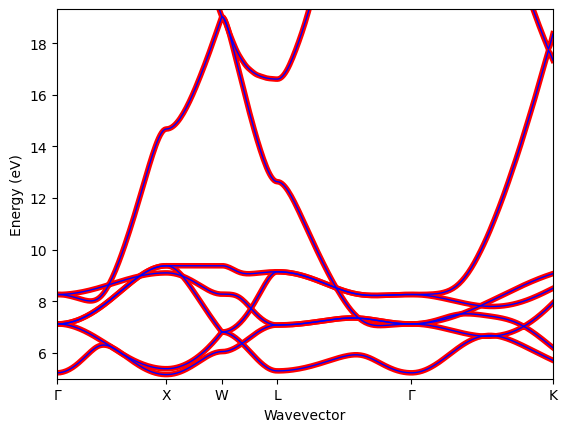

(5.0, 19.320093999999997)

In [9]:
plot_bands(Hwannier, cell_map, color="red", linewidth=4)
plot_bands("totalE.bands.eigenvals", spin=1, color="blue", linewidth=1)
label_plots()
ylim(5, 0.71/eV)

In [10]:
subsampling = returnfermikpoint(Hwannier, cell_map, 13, Val(3), num_blocks=100, mesh=10, histogram_width=1)

(Real[0.9831956932231523 0.5711771902384601 … 0.8078291442340886 0.5188718148423961; 0.842690007465692 0.4864078906890581 … 0.5236510448887468 0.7869692469619973; 0.38329672841177387 0.45002629855574017 … 0.9996707939388216 0.6076487402374857], 0.12696)

In [11]:
subsampling[1]

3×12696 Matrix{Real}:
 0.983196  0.571177  0.123491  0.473127   …  0.641519  0.807829  0.518872
 0.84269   0.486408  0.118347  0.0124292     0.903742  0.523651  0.786969
 0.383297  0.450026  0.655637  0.111549      0.170945  0.999671  0.607649

In [13]:
tau =  τ(Hwannier, cell_map, Pwannier, force_matrix, cellph_map,
    Heph, celleph_map, collect(0.01:0.01:1), 13, Val(:histogram), Val(3); histogram_width=1, supplysampling=subsampling, num_blocks=10, dosmesh=10, dos_num_blocks=10, mesh=64, fracroom=1)

DOS at Fermi Energy is: 0.13040000000000002
Sampling from 12696kpoints
Block: 1
Block: 2
Block: 3
Block: 4
Block: 5
Block: 6
Block: 7
Block: 8
Block: 9
Block: 10


100-element Vector{Float64}:
 32.972495471856945
 31.792972551486788
 30.687866599296893
 29.665106256687302
 28.728806292424487
 27.8796520212343
 27.115504031382294
 26.43209931461743
 25.823745331931597
 25.283936136138994
 24.80585313670629
 24.382740388939244
 24.00816272981895
  ⋮
 19.903074697355855
 19.895722661768136
 19.888534879250315
 19.881505906202037
 19.874630536940433
 19.867903790842647
 19.861320900312986
 19.85487729951439
 19.848568613807316
 19.84239064984546
 19.83633938628017
 19.830410965032037

In [29]:
np.savetxt("Ag_3D_tau.txt", tau)

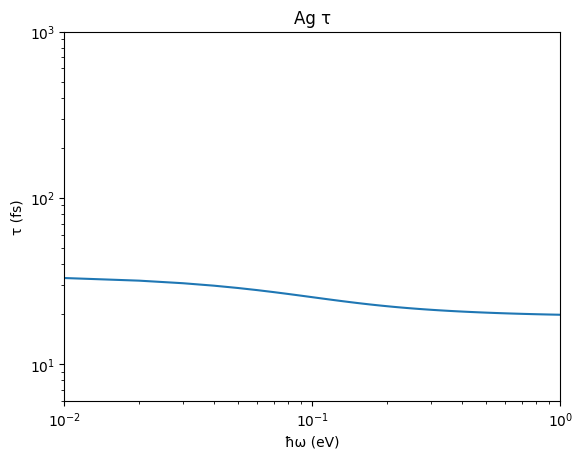

PyObject Text(24.000000000000007, 0.5, 'τ (fs)')

In [30]:
loglog(collect(0.01:0.01:1), np.loadtxt("Ag_3D_tau.txt"))
ylim(6, 1000)
xlim(0.01, 1)
title("Ag τ")
xlabel("ħω (eV)")
ylabel("τ (fs)")

In [58]:
lattice_vectors = loadlattice("totalE.out")

3-element Vector{Vector{Float64}}:
 [0.0, 2.0450045165, 2.0450045165]
 [2.0450045165, 0.0, 2.0450045165]
 [2.0450045165, 2.0450045165, 0.0]

In [87]:
drude_conductivity(lattice_vectors, Hwannier, cell_map, Pwannier, 13, Val(3), mesh=6, num_blocks=1000, histogram_width=1, degeneracy=2)

here
Block: 1
Block: 2
Block: 3
Block: 4
Block: 5
Block: 6
Block: 7
Block: 8
Block: 9
Block: 10
Block: 11
Block: 12
Block: 13
Block: 14
Block: 15
Block: 16
Block: 17
Block: 18
Block: 19
Block: 20
Block: 21
Block: 22
Block: 23
Block: 24
Block: 25
Block: 26
Block: 27
Block: 28
Block: 29
Block: 30
Block: 31
Block: 32
Block: 33
Block: 34
Block: 35
Block: 36
Block: 37
Block: 38
Block: 39
Block: 40
Block: 41
Block: 42
Block: 43
Block: 44
Block: 45
Block: 46
Block: 47
Block: 48
Block: 49
Block: 50
Block: 51
Block: 52
Block: 53
Block: 54
Block: 55
Block: 56
Block: 57
Block: 58
Block: 59
Block: 60
Block: 61
Block: 62
Block: 63
Block: 64
Block: 65
Block: 66
Block: 67
Block: 68
Block: 69
Block: 70
Block: 71
Block: 72
Block: 73
Block: 74
Block: 75
Block: 76
Block: 77
Block: 78
Block: 79
Block: 80
Block: 81
Block: 82
Block: 83
Block: 84
Block: 85
Block: 86
Block: 87
Block: 88
Block: 89
Block: 90
Block: 91
Block: 92
Block: 93
Block: 94
Block: 95
Block: 96
Block: 97
Block: 98
Block: 99
Block: 100
Blo

Block: 756
Block: 757
Block: 758
Block: 759
Block: 760
Block: 761
Block: 762
Block: 763
Block: 764
Block: 765
Block: 766
Block: 767
Block: 768
Block: 769
Block: 770
Block: 771
Block: 772
Block: 773
Block: 774
Block: 775
Block: 776
Block: 777
Block: 778
Block: 779
Block: 780
Block: 781
Block: 782
Block: 783
Block: 784
Block: 785
Block: 786
Block: 787
Block: 788
Block: 789
Block: 790
Block: 791
Block: 792
Block: 793
Block: 794
Block: 795
Block: 796
Block: 797
Block: 798
Block: 799
Block: 800
Block: 801
Block: 802
Block: 803
Block: 804
Block: 805
Block: 806
Block: 807
Block: 808
Block: 809
Block: 810
Block: 811
Block: 812
Block: 813
Block: 814
Block: 815
Block: 816
Block: 817
Block: 818
Block: 819
Block: 820
Block: 821
Block: 822
Block: 823
Block: 824
Block: 825
Block: 826
Block: 827
Block: 828
Block: 829
Block: 830
Block: 831
Block: 832
Block: 833
Block: 834
Block: 835
Block: 836
Block: 837
Block: 838
Block: 839
Block: 840
Block: 841
Block: 842
Block: 843
Block: 844
Block: 845
Block: 846

3×3 Matrix{Float64}:
 1.94345      0.00330916   0.0124504
 0.00330916   1.9378      -0.00712037
 0.0124504   -0.00712037   1.94799

In [115]:
c = interbandsigma(lattice_vectors, Hwannier, cell_map, Pwannier, 13, Val(3), mesh=5, num_blocks=10)

Block: 1
Block: 2
Block: 3
Block: 4
Block: 5
Block: 6
Block: 7
Block: 8
Block: 9
Block: 10


3×3×200 Array{ComplexF64, 3}:
[:, :, 1] =
 NaN+NaN*im  NaN+NaN*im  NaN+NaN*im
 NaN+NaN*im  NaN+NaN*im  NaN+NaN*im
 NaN+NaN*im  NaN+NaN*im  NaN+NaN*im

[:, :, 2] =
 0.0+0.0im  0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im

[:, :, 3] =
 0.0+0.0im  0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im

...

[:, :, 198] =
  -0.0365984+0.0im         -0.00385111+8.79348e-7im  -0.00127156+6.38429e-8im
 -0.00385111-8.79348e-7im   -0.0351279+0.0im           0.0071184-5.64845e-7im
 -0.00127156-6.38429e-8im    0.0071184+5.64845e-7im   -0.0341789+0.0im

[:, :, 199] =
  -0.0425628+0.0im         0.000710009+5.13502e-7im   -0.0126695+5.21014e-7im
 0.000710009-5.13502e-7im   -0.0663587+0.0im         -0.00644494-5.67325e-7im
  -0.0126695-5.21014e-7im  -0.00644494+5.67325e-7im    -0.048353+0.0im

[:, :, 200] =
  -0.0408227+0.0im          0.00961401-5.55272e-8im  -0.00377132-3.74769e-7im
  0.00961401+5.55272e-8im   -0.0482786+0.0im

In [15]:
Es, Ds = density_of_states(Hwannier, cell_map, Val(3), mesh=10, num_blocks=20, histogram_width=10, monte_carlo=true)

([4.160073897008373, 4.260202895920446, 4.360331894832519, 4.4604608937445915, 4.560589892656665, 4.660718891568738, 4.760847890480811, 4.860976889392884, 4.961105888304957, 5.061234887217029  …  30.89451660653185, 30.994645605443925, 31.094774604355997, 31.19490360326807, 31.295032602180147, 31.39516160109222, 31.495290600004292, 31.595419598916365, 31.695548597828438, 31.79567759674051], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0005  …  0.0005, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0])

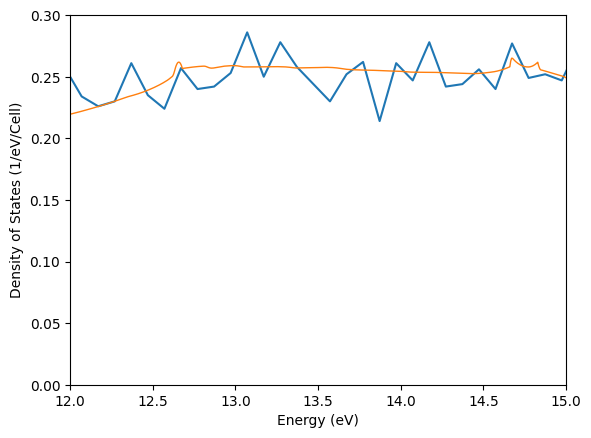

(12.0, 15.0)

In [22]:
plot(Es, Ds*2)
density_of_states("totalE.dos", linewidth=1)
ylim(0, 0.3)
xlim(12, 15)

In [31]:
pwd()

"/home/gridsan/aligho/Plasmons/Plasmons_Paper/Substitutional_Defects/Argentene/3Dnew"

In [115]:
(imag.(momentum_matrix_elements(Hwannier, cell_map, Pwannier, rand(3)))[:, 1, 1])

3-element Vector{Float64}:
  3.095489536615007e-17
 -1.1144896603968426e-16
  3.1521263531943425e-17

In [157]:
0.477751886/eV

13.0002976707004

In [118]:
imag.(momentum_matrix_elements(Hwannier, cell_map, Pwannier, k))[:, 1, 1]

3-element Vector{Float64}:
  6.055002930804655e-17
  1.3590716888912372e-16
 -2.627917897703087e-17

In [120]:
imag.(momentum_matrix_elements(Hwannier, cell_map, Pwannier, k))[1:2, 1, 1]

2-element Vector{Float64}:
 6.055002930804655e-17
 1.3590716888912372e-16